# MIG Quant Competition — Data Exploration

This notebook walks through the `dev_data.csv` dataset so you understand what your strategy receives.

**Dataset**: OHLCV data for 30 stocks.  
**Your strategy only sees the Open price** — but you can use all columns here for research.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

plt.style.use('dark_background')
sns.set_palette('husl')

pd.set_option('display.float_format', '{:.4f}'.format)
print('Imports OK')

Imports OK


## 1. Load the dataset


We use pandas data-frames to load the data from the CSV as we add the asset "Ticker" and the price "Date" as the index into the Dataframe. This allows us to index the dataframe depending on what asset we want to look at. We can also see that every asset has  *daily* price data for `Open`, `High`, `Low`, `Close`, `Adj Close`, and `Volume`.

In [18]:
# Load the CSV — adjust the path if running from a different directory
df = pd.read_csv('../dev_data.csv', parse_dates=['Date'], date_format='%Y-%m-%d', thousands=',')


# set indexes 
df.set_index(["Ticker", "Date"], inplace=True)

print('Shape:', df.shape)
print('Columns:', df.columns.tolist())
print('\nFirst 5 rows:')
df.head()

Shape: (10060, 6)
Columns: ['Open', 'High', 'Low', 'Close', 'Adj. Close', 'Volume']

First 5 rows:


Open   High    Low  Close  Adj. Close   Volume
Ticker Date                                                    
A      3/15/17 6.7000 6.7700 5.9600 6.0600      6.0600  6970100
       3/16/17 6.1000 6.2000 5.7500 5.7600      5.7600  3652400
       3/17/17 5.8100 5.8900 5.6500 5.8000      5.8000  3477100
       3/20/17 5.8500 5.8600 5.5100 5.5700      5.5700  2484100
       3/21/17 5.5600 5.6000 5.4200 5.4600      5.4600  1798400

In [19]:
# we can see that our dataframe (df) has index values of (Ticker, Date)
df.index

MultiIndex([('A', '3/15/17'),
            ('A', '3/16/17'),
            ('A', '3/17/17'),
            ('A', '3/20/17'),
            ('A', '3/21/17'),
            ('A', '3/22/17'),
            ('A', '3/23/17'),
            ('A', '3/24/17'),
            ('A', '3/27/17'),
            ('A', '3/28/17'),
            ...
            ('J',  '3/1/21'),
            ('J',  '3/2/21'),
            ('J',  '3/3/21'),
            ('J',  '3/4/21'),
            ('J',  '3/5/21'),
            ('J',  '3/8/21'),
            ('J',  '3/9/21'),
            ('J', '3/10/21'),
            ('J', '3/11/21'),
            ('J', '3/12/21')],
           names=['Ticker', 'Date'], length=10060)

In [20]:
# How many unique tickers?
tickers = sorted(df.index.get_level_values('Ticker').unique())
print(f'Unique tickers: {len(tickers)}')
print(tickers)

Unique tickers: 10
['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J']


In [33]:
# Date range
print('Date range:', df.index.get_level_values('Date').min(), '->', df.index.get_level_values('Date').max())

Date range: 1/10/18 -> 9/9/20


## 2. Build the prices matrix

This is exactly what `get_actions(prices)` receives — shape `(num_stocks, num_days)`, Open price only.

In [22]:
# Extract all Date values from the MultiIndex to compute the overall date range
prices_df = df['Open'].unstack(level='Date').sort_index()

# Forward-fill any missing days, then drop remaining NaN columns 
#(there should not be any in our data but this is good practice)
prices_df = prices_df.ffill(axis=1).dropna(axis=1)

prices = prices_df.values  # shape: (num_stocks, num_days)
print('prices matrix shape:', prices.shape)  # should be ~(50, N)
print('Row labels (tickers):', prices_df.index.tolist())

prices matrix shape: (10, 1006)
Row labels (tickers): ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J']


In [23]:
# If we want to look at the close price data for asset "A"
A_close_data = df.loc["A"]["Close"]
A_close_data

Date
3/15/17    6.0600
3/16/17    5.7600
3/17/17    5.8000
3/20/17    5.5700
3/21/17    5.4600
            ...  
3/8/21    37.1200
3/9/21    43.4000
3/10/21   44.2200
3/11/21   49.6500
3/12/21   49.2100
Name: Close, Length: 1006, dtype: float64

We can see that this data has index of "Date" and the close price data doesn't actually have a column name but can be accessed with `A_close_data.values`

In [24]:
# We can access the dates and close values separately 
# in this case the index of the data has become only the dates column
print("Date index:", A_close_data.index)
print("Close price values:", A_close_data.values)

Date index: Index(['3/15/17', '3/16/17', '3/17/17', '3/20/17', '3/21/17', '3/22/17',
       '3/23/17', '3/24/17', '3/27/17', '3/28/17',
       ...
       '3/1/21', '3/2/21', '3/3/21', '3/4/21', '3/5/21', '3/8/21', '3/9/21',
       '3/10/21', '3/11/21', '3/12/21'],
      dtype='object', name='Date', length=1006)
Close price values: [ 6.06  5.76  5.8  ... 44.22 49.65 49.21]


## 3. Price distributions

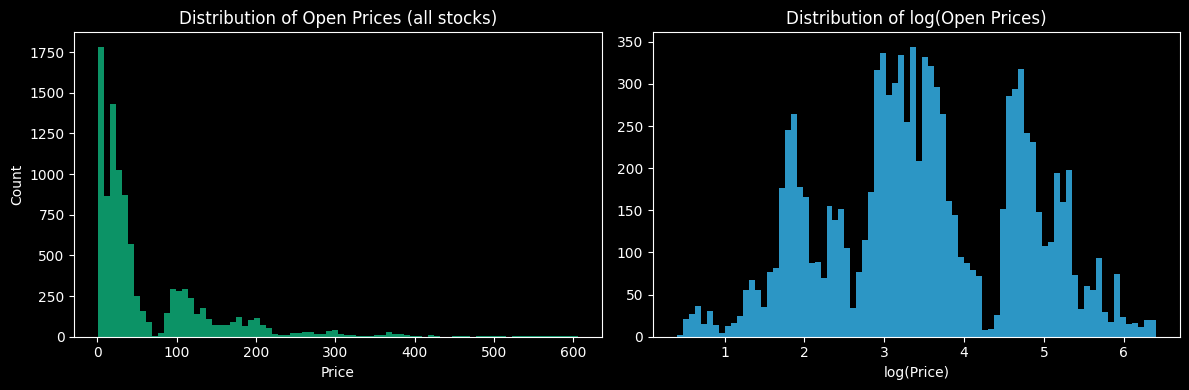

In [25]:
# Distribution of all Open prices across all stocks
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(prices.flatten(), bins=80, color='#10b981', edgecolor='none', alpha=0.8)
axes[0].set_title('Distribution of Open Prices (all stocks)')
axes[0].set_xlabel('Price')
axes[0].set_ylabel('Count')

axes[1].hist(np.log(prices.flatten()), bins=80, color='#38bdf8', edgecolor='none', alpha=0.8)
axes[1].set_title('Distribution of log(Open Prices)')
axes[1].set_xlabel('log(Price)')

plt.tight_layout()
plt.show()

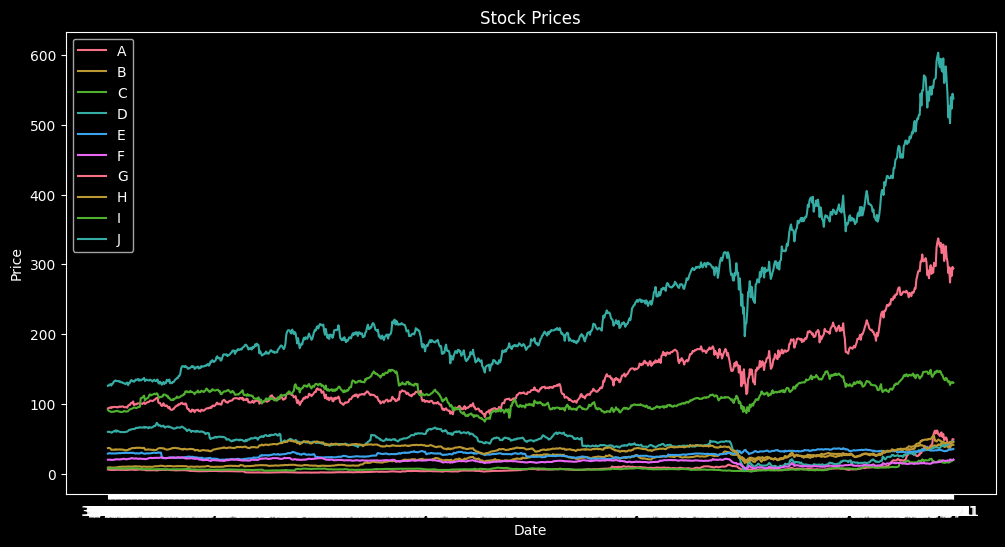

In [26]:
# We can plot all the symbols like below
tickers = sorted(df.index.get_level_values('Ticker').unique())

plt.figure(figsize=(12, 6))

for ticker in tickers:
    stock_close_data = df.loc[ticker]["Close"]
    plt.plot(stock_close_data.index,stock_close_data.values, label=f'{ticker}')

plt.xlabel('Date')
plt.ylabel('Price')
plt.title('Stock Prices')
plt.legend()
plt.show()

## 4. Price series — a few stocks

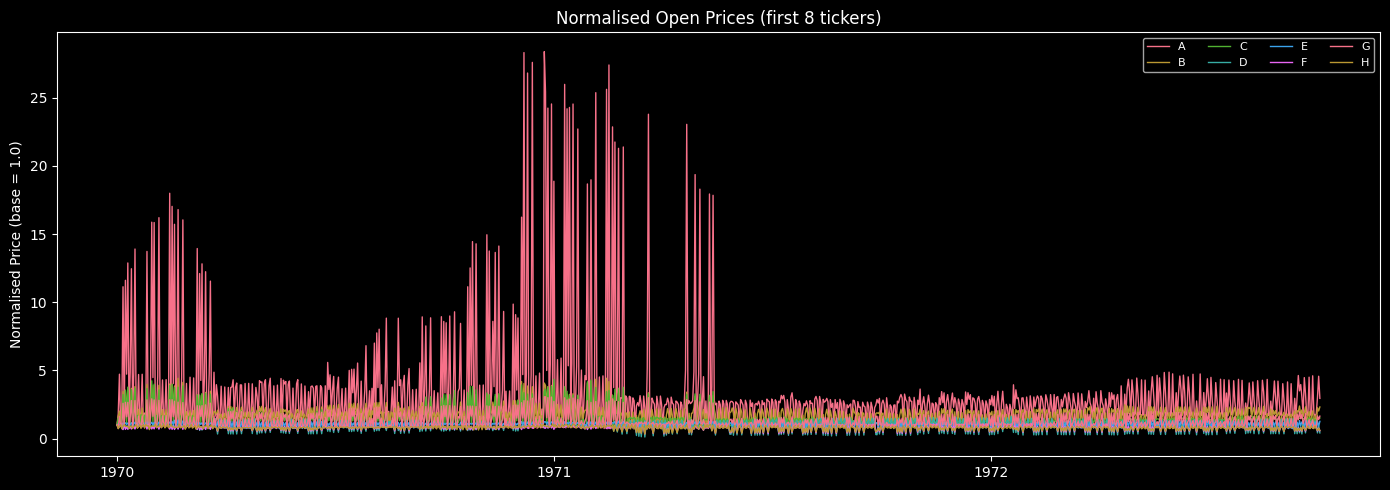

In [27]:
# Plot normalised price series for the first 8 tickers
sample_tickers = tickers[:8]
dates = prices_df.columns

fig, ax = plt.subplots(figsize=(14, 5))

for ticker in sample_tickers:
    series = prices_df.loc[ticker].values
    normalised = series / series[0]  # start at 1.0
    ax.plot(dates, normalised, linewidth=1, label=ticker)

ax.set_title('Normalised Open Prices (first 8 tickers)')
ax.set_ylabel('Normalised Price (base = 1.0)')
ax.legend(fontsize=8, ncol=4)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()

## 5. Daily returns

Mean daily return (across all stocks): 0.0001963697136795322
Std  daily return (across all stocks): 0.5864716087025454


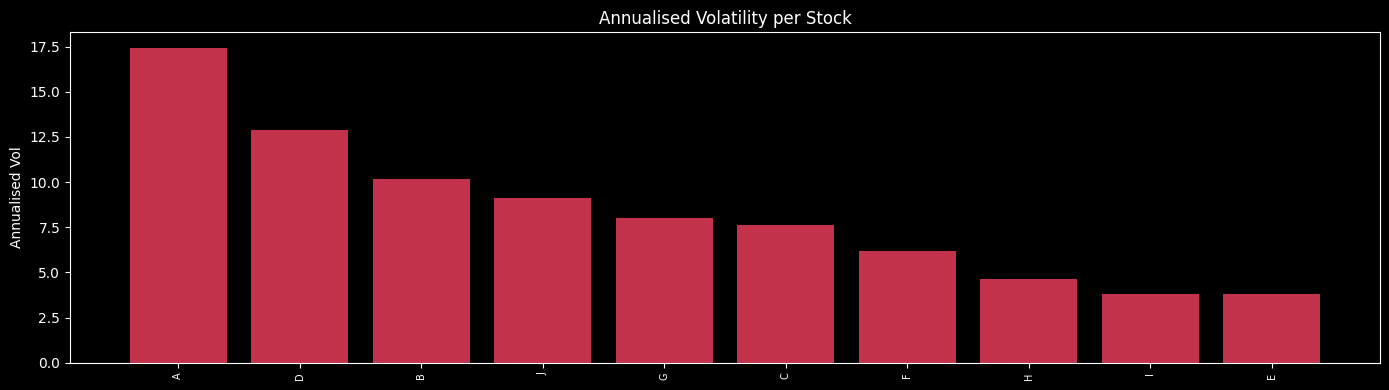

In [28]:
# Daily log returns for all stocks
log_returns = np.diff(np.log(prices), axis=1)  # shape: (num_stocks, num_days - 1)

print('Mean daily return (across all stocks):', log_returns.mean())
print('Std  daily return (across all stocks):', log_returns.std())

# Per-stock annualised volatility
ann_vol = log_returns.std(axis=1) * np.sqrt(252)
vol_df = pd.Series(ann_vol, index=prices_df.index).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(vol_df.index, vol_df.values, color='#f43f5e', alpha=0.8)
ax.set_title('Annualised Volatility per Stock')
ax.set_ylabel('Annualised Vol')
ax.tick_params(axis='x', rotation=90, labelsize=7)
plt.tight_layout()
plt.show()

## 6. Correlation matrix

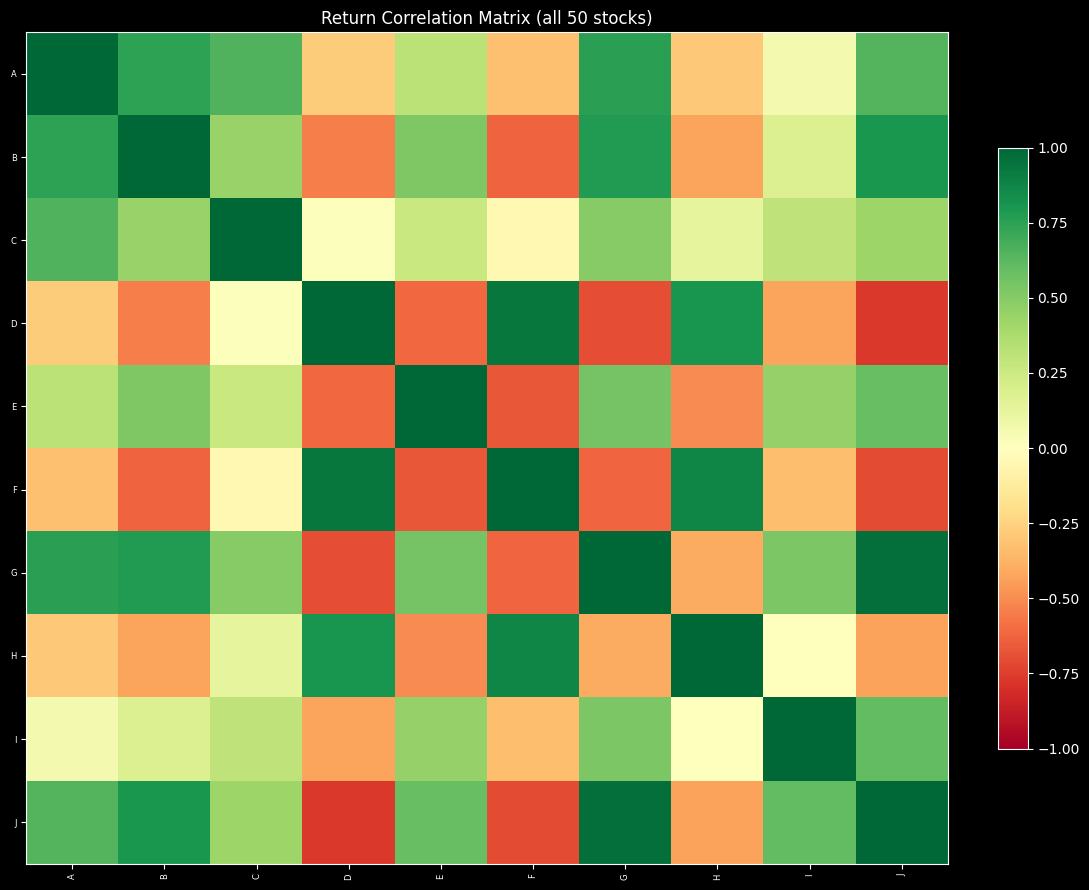

Average pairwise correlation: 0.1130
Min pairwise correlation:     -0.7699
Max pairwise correlation:     0.9635


In [29]:
# Pairwise correlation of daily returns
corr_matrix = np.corrcoef(log_returns)

fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(corr_matrix, cmap='RdYlGn', vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax, fraction=0.03)
ax.set_title('Return Correlation Matrix (all 50 stocks)')
ax.set_xticks(range(len(tickers)))
ax.set_yticks(range(len(tickers)))
ax.set_xticklabels(tickers, rotation=90, fontsize=6)
ax.set_yticklabels(tickers, fontsize=6)
plt.tight_layout()
plt.show()

# Off-diagonal stats
off_diag = corr_matrix[np.triu_indices_from(corr_matrix, k=1)]
print(f'Average pairwise correlation: {off_diag.mean():.4f}')
print(f'Min pairwise correlation:     {off_diag.min():.4f}')
print(f'Max pairwise correlation:     {off_diag.max():.4f}')

## 7. Volume analysis

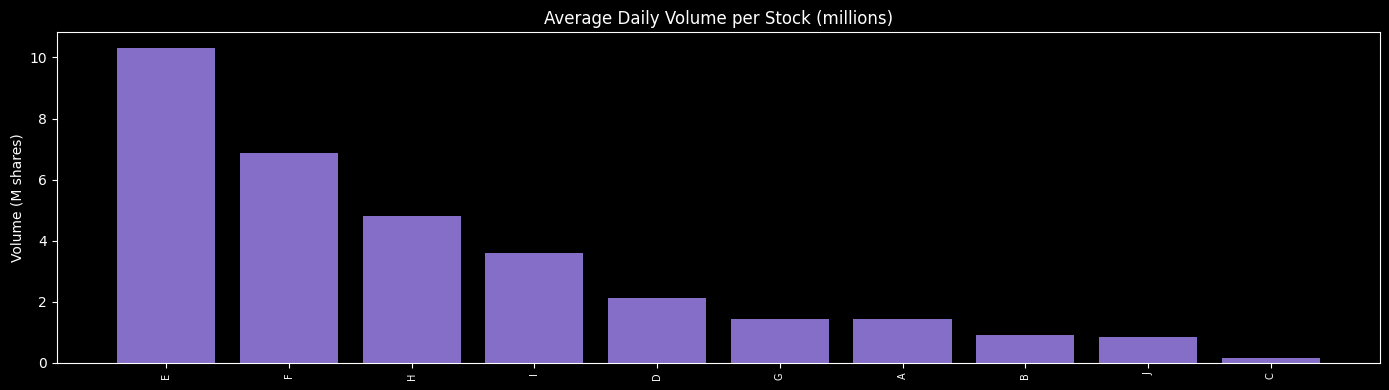

In [30]:
# Average daily volume per ticker
avg_volume = df.groupby('Ticker')['Volume'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(avg_volume.index, avg_volume.values / 1e6, color='#a78bfa', alpha=0.8)
ax.set_title('Average Daily Volume per Stock (millions)')
ax.set_ylabel('Volume (M shares)')
ax.tick_params(axis='x', rotation=90, labelsize=7)
plt.tight_layout()
plt.show()

## 8. Simple technical feature: 20-day rolling momentum

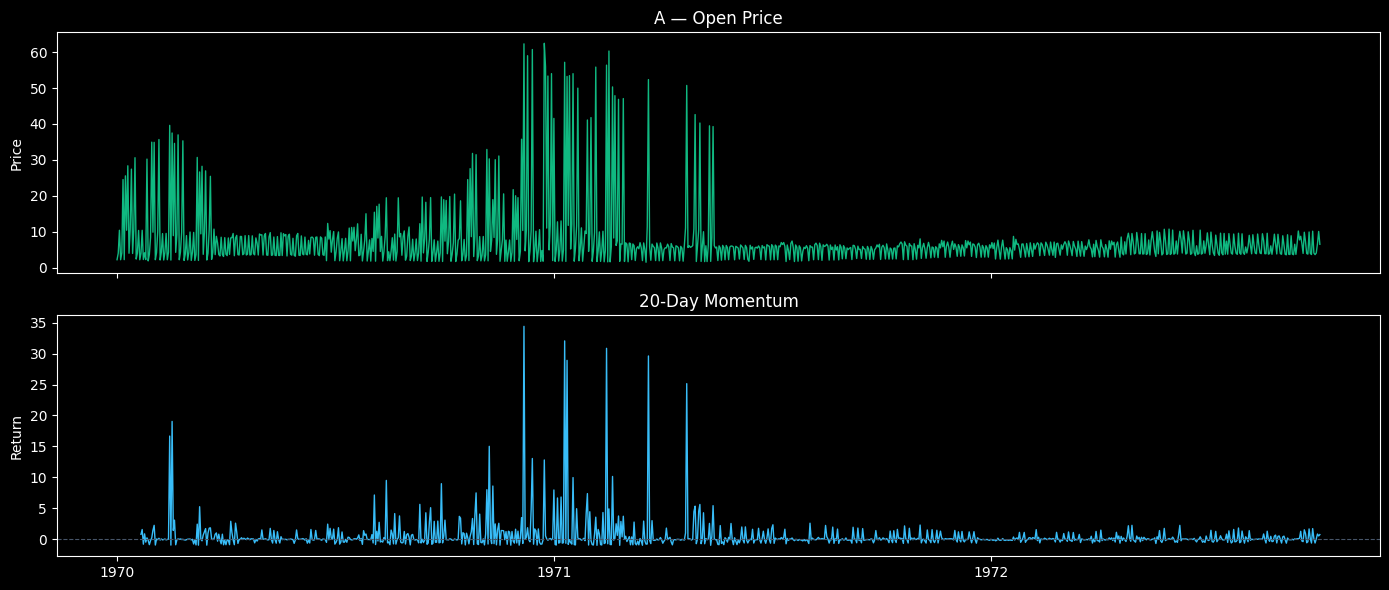

In [31]:
# 20-day rolling return (momentum signal)
# Using the first stock as an example
example_ticker = tickers[0]
series = prices_df.loc[example_ticker].values
momentum_20 = np.full_like(series, np.nan)
for t in range(20, len(series)):
    momentum_20[t] = (series[t] - series[t - 20]) / series[t - 20]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

ax1.plot(dates, series, color='#10b981', linewidth=1)
ax1.set_title(f'{example_ticker} — Open Price')
ax1.set_ylabel('Price')

ax2.plot(dates, momentum_20, color='#38bdf8', linewidth=1)
ax2.axhline(0, color='#475569', linewidth=0.8, linestyle='--')
ax2.set_title('20-Day Momentum')
ax2.set_ylabel('Return')
ax2.xaxis.set_major_locator(mdates.YearLocator())
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.show()

## 9. Convert to Numpy Arrays for Greater Analysis

It can also be useful to put the stocks prices into a Numpy array so it is easier to manipulate. Below we will do that with the stock prices. Also note here that we sort the tickers so that the first index will refer to `A`, the second to `B` and so on.

In [32]:
tickers = sorted(df.index.get_level_values('Ticker').unique())

close_prices = []

for ticker in tickers:
    stock_close_data = df.loc[ticker]["Close"]
    close_prices.append(stock_close_data.values)

close_prices = np.stack(close_prices)


print(f"Tickers {tickers}")
print(f"close_prices shape: {close_prices.shape}") # (50, 1258)
print(f"close_prices:\n{close_prices}")

Tickers ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J']
close_prices shape: (10, 1006)
close_prices:
[[  6.06   5.76   5.8  ...  44.22  49.65  49.21]
 [  8.85   9.15   9.15 ...  40.81  41.7   41.46]
 [  7.8    7.85   8.   ...  18.25  19.14  19.63]
 ...
 [ 36.78  37.1   36.62 ...  44.62  44.63  45.48]
 [ 91.51  90.2   89.59 ... 130.12 131.34 130.49]
 [126.07 126.19 127.9  ... 523.33 544.4  537.63]]


## Next steps

Open `02_strategy_development.ipynb` to build a strategy, run it through your own backtester, and inspect the results.